# Анализ лояльности пользователей Яндекс Афиши

Команда маркетинга хочет лучше понимать поведение пользователей. Для этого они просят провести исследовательский анализ данных, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. Это позволит:

- Быстро выявлять перспективных клиентов и предлагать им персонализированные условия.
- Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
- Оптимизировать маркетинговые бюджеты.
- Повысить общий уровень удержания клиентов.

Для выявления лояльных пользователей необходимо:
- Загрузить данные и преобработать их
- Построить агрегированные признаки, описывающие поведение и профиль каждого пользователя
- Исследововать признаки первого заказа и их связи с возвращением на платформу
- Исследовать поведение пользователей через показатели выручки и состава заказа
- Исследовать временные характеристики первого заказа и их влияния на повторные покупки
- Провести корреляционный анализ количества покупок и признаков пользователя

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

In [1]:
!pip install phik -q

In [2]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
import phik
from phik.report import plot_correlation_matrix

In [3]:
sns.set_theme(style="whitegrid")

In [4]:
db_config = {'user': hidden, # имя пользователя
             'pwd': hidden, # пароль
             'host': hidden,
             'port': hidden, # порт подключения
             'db': hidden # название базы данных
             }

In [5]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [6]:
engine = create_engine(connection_string)

In [7]:
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT user_id, device_type_canonical, order_id, created_dt_msk AS order_dt, created_ts_msk AS order_ts, currency_code, revenue, tickets_count,
  CASE
    WHEN LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk) IS NULL THEN NULL
    ELSE EXTRACT(DAY FROM (created_dt_msk - LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk)))::INTEGER
  END AS days_since_prev,
event_id, event_name_code AS event_name, event_type_main, service_name, region_name, city_name
FROM afisha.purchases
JOIN afisha.events USING (event_id)
JOIN afisha.city USING (city_id)
JOIN afisha.regions USING (region_id)
WHERE device_type_canonical IN ('mobile', 'desktop') AND event_type_main NOT IN ('фильм')
ORDER BY user_id;
'''

In [8]:
df = pd.read_sql_query(query, con=engine)

In [9]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


Подключение к БД прошло успешно. SQL запрос сформирован и применен, результат его выполнения теперь хранится в df.

---

#### Изучение общей информации о выгруженных данных. Оценка корректности выгрузки и объёма полученных данных. 

---

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Выгружено 15 необходимых столбцов. В большинстве столбцах хранятся данные типа object. Дата и время заказа имеют тип datetime64. Айди заказа и события, количество билетов int64. Выручка и почему-то дни с последнего заказа float64. days_since_prev надо исправить, хотя в среде SQL все корректно преобразовывалось. Всего записей в датафрейме 290611, с учетом всех произведенных фильтраций. Возможно стоит преобразовать device_type_canonical, currency_code, event_type_main в категориальный тип данных для удобства и оптимизации.

---

###  2. Предобработка данных

---

#### Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведем выручку к единой валюте - российскому рублю.

---


In [11]:
cur = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [12]:
cur.head(10)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
5,2024-01-15,100,19.4501,kzt
6,2024-01-16,100,19.4264,kzt
7,2024-01-17,100,19.4177,kzt
8,2024-01-18,100,19.5798,kzt
9,2024-01-19,100,19.5741,kzt


In [13]:
cur.rename(columns={'data': 'order_dt'}, inplace=True)
cur['order_dt'] = cur['order_dt'].astype('datetime64[ns]')

In [14]:
df = pd.merge(df, cur, on ='order_dt', how ='left')
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,nominal,curs,cdx
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,100,18.6972,kzt
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,100,18.3419,kzt
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,100,19.6475,kzt
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,100,18.5010,kzt
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,100,19.6648,kzt


In [15]:
def calculate_rub(row):
    if row['currency_code'] == 'kzt':
        return row['revenue'] * row['curs'] / 100
    else:
        return row['revenue']

df['revenue_rub'] = df.apply(calculate_rub, axis=1)

In [16]:
df = df.drop(['nominal', 'curs', 'cdx'], axis='columns')

In [17]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


Теперь есть столбец revenue_rub, где хранится информация о выручке именно в рублях. Этот столбец и будет использоваться для дальнейшей работы.

---

#### Обработка пропусков, типов и значений в данных

---

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [19]:
missing_values = df.isna().sum()
print("Пропущенные значения в столбцах:")
print(missing_values[missing_values > 0])

Пропущенные значения в столбцах:
days_since_prev    21933
dtype: int64


Пропуски есть только в days_since_prev, они имеют вид NaN (Not a Number). 

In [20]:
df['days_since_prev'] = (
    pd.to_numeric(df['days_since_prev'], errors='coerce')
    .astype('float32')
)

In [21]:
int_cols = ['order_id', 'tickets_count', 'event_id']
for col in int_cols:
    df[col] = pd.to_numeric(df[col], downcast='integer')

float_cols = ['revenue', 'revenue_rub', 'days_since_prev']
for col in float_cols:
    df[col] = pd.to_numeric(df[col], downcast='float')

cat_cols = ['device_type_canonical', 'currency_code', 'event_type_main']
for col in cat_cols:
    df[col] = df[col].astype('category')

In [22]:
object_cols = df.select_dtypes(include=['object']).columns

for col in object_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

cols = ['service_name', 'region_name', 'city_name', 'event_type_main', 'device_type_canonical', 'currency_code']
for col in cols:
    unique_vals = df[col].unique()
    print(f"Уникальные значения в '{col}'")
    print(unique_vals)

Уникальные значения в 'service_name'
['край билетов' 'мой билет' 'за билетом!' 'лови билет!'
 'билеты без проблем' 'облачко' 'лучшие билеты' 'прачечная' 'быстробилет'
 'дом культуры' 'весь в билетах' 'билеты в руки' 'тебе билет!'
 'show_ticket' 'городской дом культуры' 'яблоко' 'билет по телефону'
 'выступления.ру' 'росбилет' 'шоу начинается!' 'мир касс' 'восьмёрка'
 'телебилет' 'crazy ticket!' 'реестр' 'быстрый кассир' 'карандашру'
 'радио ticket' 'дырокол' 'вперёд!' 'кино билет' 'цвет и билет' 'зе бест!'
 'тех билет' 'лимоны' 'билеты в интернете']
Уникальные значения в 'region_name'
['каменевский регион' 'североярская область' 'озернинский край'
 'лугоградская область' 'поленовский край' 'широковская область'
 'медовская область' 'златопольский округ' 'малиновоярский округ'
 'яблоневская область' 'ветренский регион' 'боровлянский край'
 'крутоводская область' 'ягодиновская область' 'серебряноярский округ'
 'лесодальний край' 'верхоречная область' 'горицветская область'
 'речиновская 

         revenue_rub  tickets_count
count  290611.000000  290611.000000
mean      555.571960       2.754311
std       875.498169       1.170620
min       -90.760002       1.000000
25%       113.970001       2.000000
50%       351.140015       3.000000
75%       802.049988       4.000000
max     81174.539062      57.000000


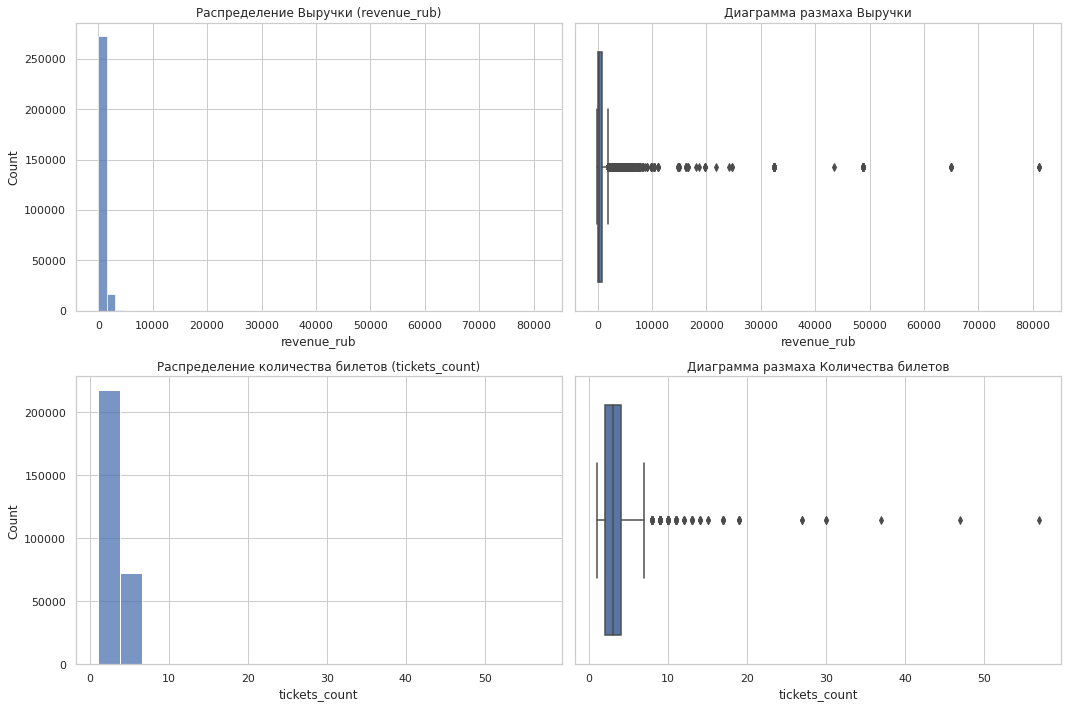

In [23]:
print(df[['revenue_rub', 'tickets_count']].describe())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['revenue_rub'], bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Распределение Выручки (revenue_rub)')

sns.boxplot(x=df['revenue_rub'], ax=axes[0, 1])
axes[0, 1].set_title('Диаграмма размаха Выручки')

sns.histplot(df['tickets_count'], bins=20, ax=axes[1, 0])
axes[1, 0].set_title('Распределение количества билетов (tickets_count)')

sns.boxplot(x=df['tickets_count'], ax=axes[1, 1])
axes[1, 1].set_title('Диаграмма размаха Количества билетов')

plt.tight_layout()
plt.show()

In [24]:
(df[df['revenue_rub'] < 0].sort_values('revenue_rub')).head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
226267,c02e67523e534d6,mobile,1740146,2024-10-29,2024-10-29 18:58:02,rub,-90.760002,5,0.0,570411,e118387a-3a7e-4932-a92c-e8dd5d234643,спорт,билеты в руки,медовская область,радужсвет,-90.760002
85635,3ee7dc2e115847f,mobile,1599206,2024-09-19,2024-09-19 09:07:24,rub,-17.940001,5,1.0,568916,b1a3919a-5d3e-4da2-b6f5-eccb480d810c,другое,билеты в руки,малиновая область,зеленополье,-17.940001
288819,fe237d2cfd6e503,mobile,6804329,2024-10-11,2024-10-11 10:49:27,rub,-10.770000,3,0.0,568916,b1a3919a-5d3e-4da2-b6f5-eccb480d810c,другое,билеты в руки,малиновая область,зеленополье,-10.770000
119844,586f795f132bf46,mobile,2489390,2024-09-26,2024-09-26 09:42:57,rub,-10.770000,3,0.0,568916,b1a3919a-5d3e-4da2-b6f5-eccb480d810c,другое,билеты в руки,малиновая область,зеленополье,-10.770000
227531,c1c7641fd348ed1,mobile,521537,2024-10-24,2024-10-24 09:04:00,rub,-10.770000,3,0.0,568916,b1a3919a-5d3e-4da2-b6f5-eccb480d810c,другое,билеты в руки,малиновая область,зеленополье,-10.770000


In [25]:
columns_to_dupl = ['user_id', 'order_ts', 'device_type_canonical',
'service_name', 'event_id', 'revenue']
df[columns_to_dupl].duplicated().sum()

df[df[columns_to_dupl].duplicated(keep=False)].head(6)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
11758,06eb7897f65b433,mobile,1123867,2024-08-13,2024-08-13 16:31:07,rub,69.820000,1,0.0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,билеты в руки,светополянский округ,глиноград,69.820000
11761,06eb7897f65b433,mobile,1123983,2024-08-13,2024-08-13 16:31:07,rub,69.820000,1,0.0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,билеты в руки,светополянский округ,глиноград,69.820000
26876,0dc525d7bacbb0d,desktop,1930705,2024-07-31,2024-07-31 13:26:11,rub,1556.050049,3,0.0,393430,b33d7a0b-a715-47e3-803e-02482884a73e,концерты,лови билет!,каменевский регион,глиногорск,1556.050049
26877,0dc525d7bacbb0d,desktop,1930763,2024-07-31,2024-07-31 13:26:11,rub,1556.050049,3,0.0,393430,b33d7a0b-a715-47e3-803e-02482884a73e,концерты,лови билет!,каменевский регион,глиногорск,1556.050049
53681,206ea45ec11d478,mobile,1935113,2024-10-29,2024-10-29 16:46:54,rub,601.690002,2,0.0,442183,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерты,билеты в руки,каменевский регион,глиногорск,601.690002
53682,206ea45ec11d478,mobile,1935171,2024-10-29,2024-10-29 16:46:54,rub,601.690002,2,0.0,442183,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерты,билеты в руки,каменевский регион,глиногорск,601.690002


In [26]:
rows_before = len(df)

negative_revenue_count = (df['revenue_rub'] < 0).sum()
negative_revenue_share = negative_revenue_count / rows_before * 100

print(f"Количество строк с отрицательной выручкой: "
      f"{negative_revenue_count} ({negative_revenue_share:.3f}%)")

revenue_99_perc = df.loc[
    df['revenue_rub'] >= 0,
    'revenue_rub'
].quantile(0.99)

print(f"99-й перцентиль для revenue_rub: {revenue_99_perc:.2f} руб.")

df_filtered = df.loc[
    (df['revenue_rub'] >= 0) &
    (df['revenue_rub'] <= revenue_99_perc)
].copy()

df_filtered.drop_duplicates(subset=columns_to_dupl, inplace=True)

rows_after = len(df_filtered)
rows_dropped = rows_before - rows_after
percent_dropped = rows_dropped / rows_before * 100

print(f"Строк до фильтрации: {rows_before}")
print(f"Строк после фильтрации: {rows_after}")
print(f"Всего удалено строк: {rows_dropped} ({percent_dropped:.2f}%)")

Количество строк с отрицательной выручкой: 381 (0.131%)
99-й перцентиль для revenue_rub: 2628.42 руб.
Строк до фильтрации: 290611
Строк после фильтрации: 287363
Всего удалено строк: 3248 (1.12%)


Пропуски действительно были только в days_since_prev (21933). Средняя выручка с заказа 555.57 руб, в среднем в заказе 2.75 билетов (2-3 билета, ближе к 3). Произведена оптимизация типов данных. Даты уже находились в корректном формате datetime64. Численные типы int64 и float64 были понижены до менее объемных форматов, а часть строк переведена в тип category. Это позволило существенно сократить объем потребляемой памяти. Текстовые данные приведены к единому стандарту (нижний регистр, удаление пробелов по краям), у категорий событий есть значение "другое". В revenue_rub были обнаружены отрицательные значения, 381 строка были удалены. Анализ ключевых метрик (revenue_rub и tickets_count) показал наличие значительных выбросов (аномально большие суммы заказов), сильно искажающих распределение. В соответствии с бизнес-логикой, данные были очищены от экстремальных выбросов. Был рассчитан 99-й перцентиль для столбца revenue_rub (2628.42 руб.). Датафрейм был отфильтрован: удалено 1.12% данных (3248 строк). Потеря такого объема данных допустима и позволит строить более точные и устойчивые аналитические модели в дальнейшем. Объем выборки составлял 290611 строк, после фильтрации 287363 строк.

---

### 3. Создание профиля пользователя

---

#### Создадим профиль пользователя:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

---


In [27]:
df_sorted = df_filtered.sort_values(by=['user_id', 'order_ts'])

user_profile = df_sorted.groupby('user_id').agg(
    first_order_dt=('order_dt', 'min'),
    last_order_dt=('order_dt', 'max'),
    
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_partner=('service_name', 'first'),
    first_genre=('event_type_main', 'first'),
    
    total_orders=('order_id', 'nunique'),
    
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_since_prev=('days_since_prev', 'mean')
).reset_index()


user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

display(user_profile.head())

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_partner,first_genre,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.939941,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,774.010010,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,767.213318,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830017,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,61.309998,1.500000,16.0,1,0


Теперь для каждого пользователя создан профиль, добавлены бинарные признаки обозначающие категорию пользователя по совершенным заказам (2 и более, 5 и более). 

---

#### Изучение данных


In [28]:
total_users = len(user_profile)
mean_avg_revenue = user_profile['avg_revenue_rub'].mean()
share_is_two = user_profile['is_two'].mean() * 100 
share_is_five = user_profile['is_five'].mean() * 100

print(f"Общее число пользователей: {total_users}")
print(f"Средняя выручка с одного заказа (в среднем по пользователям): {mean_avg_revenue:.2f} руб.")
print(f"Доля пользователей с 2+ заказами: {share_is_two:.2f}%")
print(f"Доля пользователей с 5+ заказами: {share_is_five:.2f}%\n")

print("Статистика по заказам, билетам и дням между покупками:")
cols_to_describe = ['total_orders', 'avg_tickets_count', 'avg_days_since_prev']
display(user_profile[cols_to_describe].describe())

Общее число пользователей: 21838
Средняя выручка с одного заказа (в среднем по пользователям): 545.03 руб.
Доля пользователей с 2+ заказами: 61.70%
Доля пользователей с 5+ заказами: 28.99%

Статистика по заказам, билетам и дням между покупками:


,total_orders,avg_tickets_count,avg_days_since_prev
count,21838.000000,21838.000000,13511.000000
mean,13.158852,2.744062,15.847805
std,121.564590,0.913068,22.304354
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.080000,20.414286
max,10168.000000,11.000000,148.000000


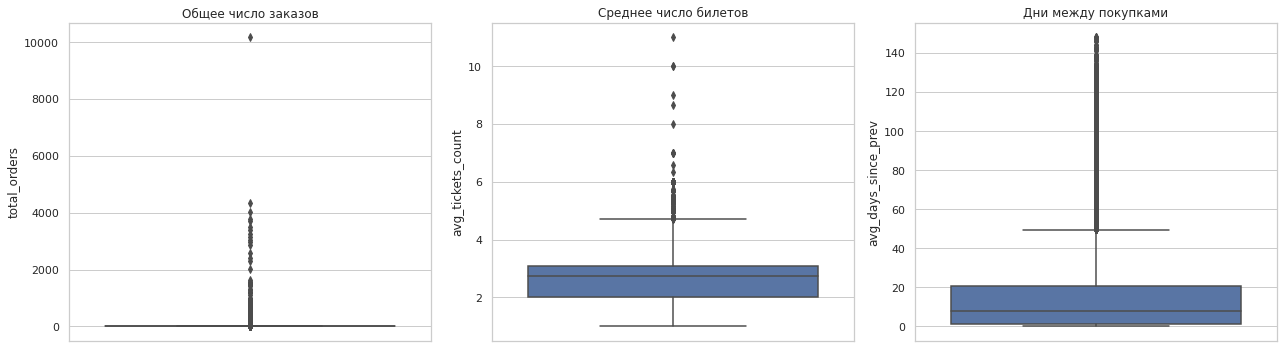

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=user_profile['total_orders'], ax=axes[0])
axes[0].set_title('Общее число заказов')

sns.boxplot(y=user_profile['avg_tickets_count'], ax=axes[1])
axes[1].set_title('Среднее число билетов')

sns.boxplot(y=user_profile['avg_days_since_prev'], ax=axes[2])
axes[2].set_title('Дни между покупками')

plt.tight_layout()
plt.show()

In [30]:
p99_orders = user_profile['total_orders'].quantile(0.99)
p99_tickets = user_profile['avg_tickets_count'].quantile(0.99)

print(f"99-й перцентиль по заказам: {p99_orders}")
print(f"99-й перцентиль по билетам: {p99_tickets}\n")

user_profile_clean = user_profile[
    (user_profile['total_orders'] <= p99_orders) &
    (user_profile['avg_tickets_count'] <= p99_tickets)
]

users_before = len(user_profile)
users_after = len(user_profile_clean)
users_dropped = users_before - users_after
percent_dropped = (users_dropped / users_before) * 100

print(f"Пользователей до фильтрации: {users_before}")
print(f"Пользователей после фильтрации: {users_after}")
print(f"Удалено профилей: {users_dropped} ({percent_dropped:.2f}%)\n")

print("Статистика ПОСЛЕ фильтрации:")
display(user_profile_clean[['total_orders', 'avg_tickets_count', 'avg_days_since_prev']].describe())

99-й перцентиль по заказам: 152.0
99-й перцентиль по билетам: 5.0

Пользователей до фильтрации: 21838
Пользователей после фильтрации: 21428
Удалено профилей: 410 (1.88%)

Статистика ПОСЛЕ фильтрации:


,total_orders,avg_tickets_count,avg_days_since_prev
count,21428.000000,21428.000000,13231.000000
mean,6.538221,2.714772,16.143236
std,14.364726,0.864831,22.409731
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.400000
50%,2.000000,2.750000,8.411765
75%,5.000000,3.017920,20.833334
max,152.000000,5.000000,148.000000


По объему данных о пользователях достаточно (21838). Аномальные значения присутствуют, максимально у одного пользователя обнаружено 10168 заказов, стандартное отклонение из-за этого высокое (121.57). В количестве билетов и прошедших дней аномалий нет. Данные отфильтрованы по 99-му перцентилю - теперь максимум 152 заказов у пользователя (вероятно существуют ценители различных мероприятий), удалено 410 профилей пользователей (возможно это были какие-то предприятия или агентства, или же ошибочные данные).

---

### 4. Исследовательский анализ данных


#### Исследование признаков первого заказа и их связи с возвращением на платформу

---

#### Группировка пользователей по сегментам

---


In [31]:
features_to_analyze = {
    'first_genre': 'Тип первого мероприятия',
    'first_device': 'Тип устройства',
    'first_region': 'Регион',
    'first_partner': 'Билетный партнер'
}

for col, name in features_to_analyze.items():
    counts = user_profile_clean[col].value_counts()
    
    shares = user_profile_clean[col].value_counts(normalize=True) * 100
    
    stat_df = pd.DataFrame({
        'Количество пользователей': counts,
        'Доля (%)': shares.round(2)
    })
    
    print(f"\n{'='*50}")
    print(f"Распределение по признаку: {name} ({col})")
    print(f"{'='*50}")
    
    display(stat_df.head(10))


Распределение по признаку: Тип первого мероприятия (first_genre)


,Количество пользователей,Доля (%)
концерты,9518,44.42
другое,5320,24.83
театр,4210,19.65
стендап,1096,5.11
спорт,779,3.64
выставки,410,1.91
ёлки,95,0.44



Распределение по признаку: Тип устройства (first_device)


,Количество пользователей,Доля (%)
mobile,17751,82.84
desktop,3677,17.16



Распределение по признаку: Регион (first_region)


,Количество пользователей,Доля (%)
каменевский регион,7032,32.82
североярская область,3716,17.34
широковская область,1209,5.64
озернинский край,671,3.13
малиновоярский округ,522,2.44
шанырский регион,502,2.34
травяная область,484,2.26
светополянский округ,455,2.12
речиновская область,437,2.04
яблоневская область,406,1.89



Распределение по признаку: Билетный партнер (first_partner)


,Количество пользователей,Доля (%)
билеты без проблем,5096,23.78
мой билет,2948,13.76
лови билет!,2790,13.02
билеты в руки,2536,11.83
облачко,2166,10.11
весь в билетах,1275,5.95
лучшие билеты,1171,5.46
прачечная,579,2.70
край билетов,452,2.11
дом культуры,353,1.65


Тип первого мероприятия: на первом месте концерты (44.42%) - в принципе это можно назвать точкой входа, на втором и третьем местах "другое" (24.83%) и театр (19.65%).
Тип устройства: с мобильных (82.84%) больше всего заказов.
Регион: в регионах лидирует каменевский регион (32.82%), за ним сразу североярская область (17.34%) - культурные и активные места.
Билетный партнер: чаще всего берут у "билеты без проблем" (23.78%) и "мой билет" (13.76%) с "лови билет" (13.02%).

Равномерно распределения в каждой категории не наблюдается.

---

#### Возвраты пользователей

---


Глобальная доля возврата (2+ заказа): 61.58%



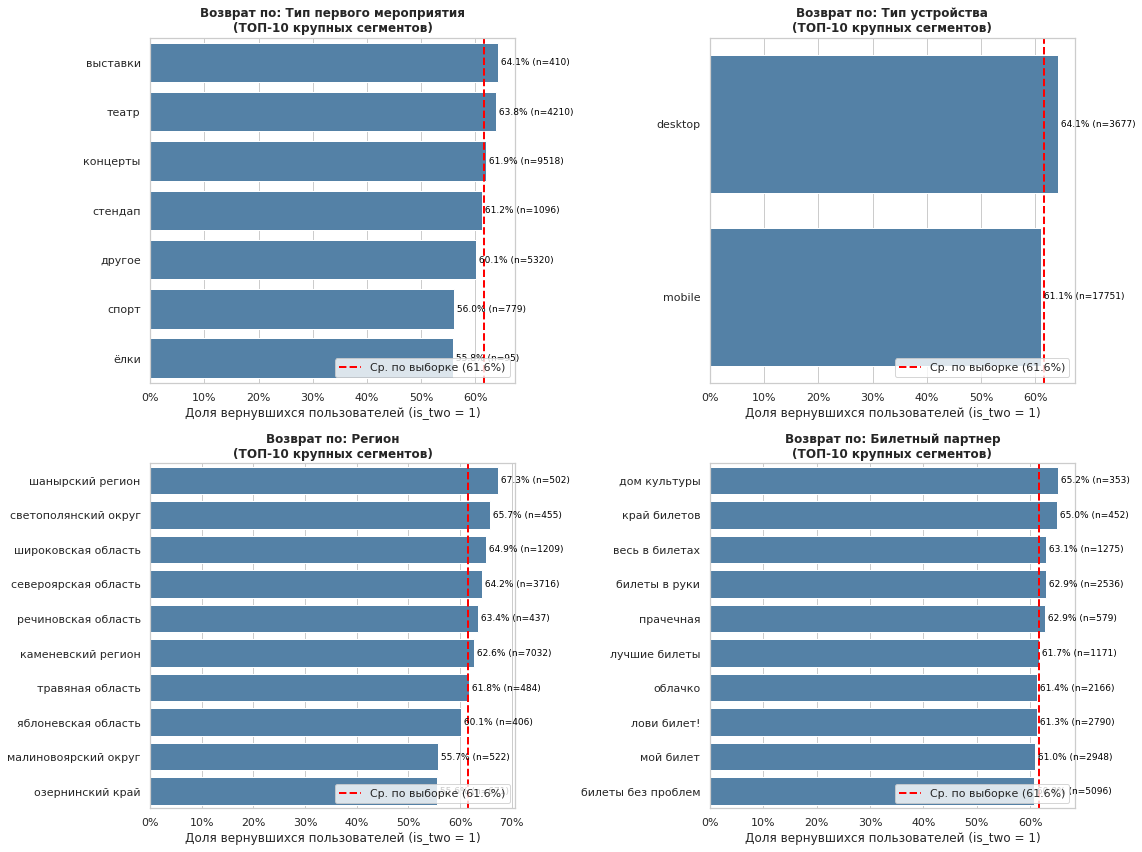

In [32]:
global_retention = user_profile_clean['is_two'].mean()
print(f"Глобальная доля возврата (2+ заказа): {global_retention:.2%}\n")

features_to_analyze = {
    'first_genre': 'Тип первого мероприятия',
    'first_device': 'Тип устройства',
    'first_region': 'Регион',
    'first_partner': 'Билетный партнер'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (col, name) in enumerate(features_to_analyze.items()):
    segment_stats = user_profile_clean.groupby(col)['is_two'].agg(['count', 'mean']).reset_index()
    
    top10_segments = segment_stats.nlargest(10, 'count')
    
    top10_segments = top10_segments.sort_values(by='mean', ascending=False)
    
    ax = axes[i]
    sns.barplot(
        data=top10_segments, 
        x='mean', 
        y=col, 
        ax=ax, 
        color='steelblue'
    )
    
    ax.axvline(global_retention, color='red', linestyle='--', linewidth=2, 
               label=f'Ср. по выборке ({global_retention:.1%})')
    
    ax.set_title(f'Возврат по: {name}\n(ТОП-10 крупных сегментов)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Доля вернувшихся пользователей (is_two = 1)')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(loc='lower right')
    
    for index, row in enumerate(top10_segments.itertuples()):
        text_label = f" {row.mean:.1%} (n={int(row.count)})"
        ax.text(row.mean, index, text_label, color='black', va="center", fontsize=9)

plt.tight_layout()
plt.show()

Чаще всего на Яндекс Афишу возвращаются пользователи с первым мероприятием в виде выставок, компьютером как устройством, из Шанырского региона, купившие билеты у Дома культуры.

- Тип первого мероприятия: чаще чем в среднем по выборке совершают повторные заказы клиенты с первыми мероприятиями выставки, театр, концерты.
- Тип устройства: пользователи с первым устройством в виде компьютера чаще снова совершают заказы.
- Регион: чаще возвращаются пользователи из Шанырского региона, Светополянского округа, Широковской области, Североярской области, Речиновской области, Кменевского региона и Травяной области.
- Билетный партнер: по доли возвратов пользователей лидируют Дом культуры, Край билетов, Весь в билетах, Билеты в руки, Прачечная.

---

#### Проверка гипотез

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [33]:
alpha = 0.05

print("==="*15)
print("ПРОВЕРКА ГИПОТЕЗЫ 1")
print("==="*15)


sports_users = user_profile_clean[user_profile_clean['first_genre'] == 'спорт']['is_two']
concerts_users = user_profile_clean[user_profile_clean['first_genre'] == 'концерты']['is_two']

successes = [sports_users.sum(), concerts_users.sum()]
nobs = [len(sports_users), len(concerts_users)]

stat, p_value_h1 = proportions_ztest(count=successes, nobs=nobs, alternative='larger')

print(f"Доля возврата 'Спорт': {sports_users.mean():.2%}")
print(f"Доля возврата 'Концерты': {concerts_users.mean():.2%}")
print(f"P-value: {p_value_h1:.5f}")

if p_value_h1 < alpha:
    print("Результат: Отвергаем нулевую гипотезу. Разница статистически значима.")
    print("Вывод: Пользователи, пришедшие через спорт, действительно возвращаются чаще, чем через концерты.")
else:
    print("Результат: Не получилось отвергнуть нулевую гипотезу.")
    print("Вывод: Статистически значимых доказательств того, что со 'Спорта' возвращаются чаще, нет (разница случайна или в пользу 'Концертов').")

print("\n" + "===" * 15)
print("ПРОВЕРКА ГИПОТЕЗЫ 2")
print("===" * 15)

region_stats = user_profile_clean.groupby('first_region')['is_two'].agg(['count', 'mean']).reset_index()

region_stats_filtered = region_stats[region_stats['count'] >= 50]

correlation, p_value_h2 = stats.pearsonr(region_stats_filtered['count'], region_stats_filtered['mean'])

print(f"Коэффициент корреляции Пирсона: {correlation:.3f}")
print(f"P-value: {p_value_h2:.5f}")

if p_value_h2 < alpha and correlation > 0:
    print("Результат: Отвергаем нулевую гипотезу.")
    print("Вывод: Гипотеза подтверждается. Существует статистически значимая связь: чем больше активных пользователей в регионе, тем выше там доля возвратов.")
elif p_value_h2 < alpha and correlation < 0:
    print("Результат: Отвергаем нулевую гипотезу, НО корреляция отрицательная.")
    print("Вывод: Гипотеза не подтверждается. Связь обратная: в крупных регионах процент возврата НИЖЕ.")
else:
    print("Результат: Не получилось отвергнуть нулевую гипотезу.")
    print("Вывод: Статистически значимой зависимости между популярностью региона и долей возвратов не обнаружено.")

ПРОВЕРКА ГИПОТЕЗЫ 1
Доля возврата 'Спорт': 55.97%
Доля возврата 'Концерты': 61.91%
P-value: 0.99948
Результат: Не получилось отвергнуть нулевую гипотезу.
Вывод: Статистически значимых доказательств того, что со 'Спорта' возвращаются чаще, нет (разница случайна или в пользу 'Концертов').

ПРОВЕРКА ГИПОТЕЗЫ 2
Коэффициент корреляции Пирсона: 0.187
P-value: 0.23644
Результат: Не получилось отвергнуть нулевую гипотезу.
Вывод: Статистически значимой зависимости между популярностью региона и долей возвратов не обнаружено.


---

#### Исследование поведения пользователей через показатели выручки и состава заказа

---

#### Проверка связи между средней выручкой сервиса с заказа и повторными заказами

---


Медианная выручка (1 заказ): 374.95 руб.
Медианная выручка (2+ заказов): 495.92 руб.


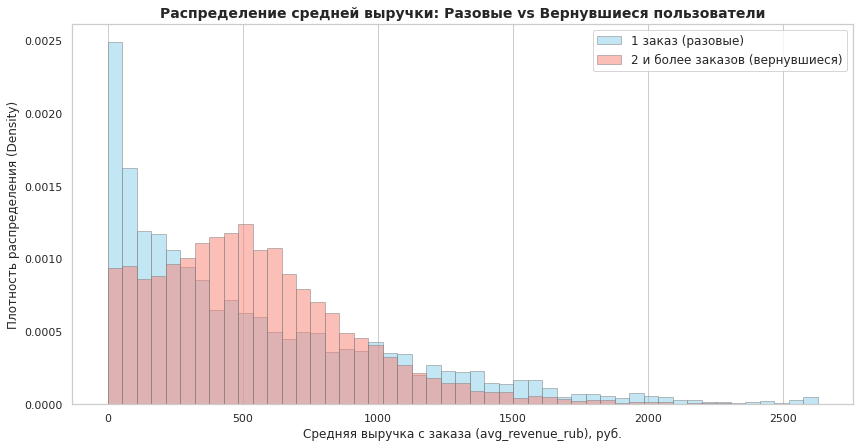

In [34]:
revenue_one_order = user_profile_clean[user_profile_clean['is_two'] == 0]['avg_revenue_rub']
revenue_multi_order = user_profile_clean[user_profile_clean['is_two'] == 1]['avg_revenue_rub']

min_rev = user_profile_clean['avg_revenue_rub'].min()
max_rev = user_profile_clean['avg_revenue_rub'].max()
bins_shared = np.linspace(min_rev, max_rev, 50)

plt.figure(figsize=(14, 7))

plt.hist(revenue_one_order, bins=bins_shared, density=True, alpha=0.5, 
         color='skyblue', edgecolor='grey', label='1 заказ (разовые)')
plt.hist(revenue_multi_order, bins=bins_shared, density=True, alpha=0.5, 
         color='salmon', edgecolor='grey', label='2 и более заказов (вернувшиеся)')

plt.title('Распределение средней выручки: Разовые vs Вернувшиеся пользователи', fontsize=14, fontweight='bold')
plt.xlabel('Средняя выручка с заказа (avg_revenue_rub), руб.', fontsize=12)
plt.ylabel('Плотность распределения (Density)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

print(f"Медианная выручка (1 заказ): {revenue_one_order.median():.2f} руб.")
print(f"Медианная выручка (2+ заказов): {revenue_multi_order.median():.2f} руб.")

plt.show()

Пользователи с разовым заказом концентрируются у небольших значений примерно до 350 рублей, а вернувшиеся пользователи - у 500 рублей. Это подтверждают медианные значения выручки.

У групп наблюдаются различия, у разовых клиентов больше заказов в диапазоне 0-350 рублей и 1000-2700 рублей. При этом вернувшиеся клиенты преобладают в диапазоне 350-1000 рублей. Т.е. разовые клиенты чаще приносят выручку близкую к минимальной или максимальной, а вернувшиеся в среднем 500 рублей.

---

#### Распределение по средней выручке с заказа в двух группах пользователей

---


Медианная средняя выручка (2-4 заказа): 471.04 руб.
Медианная средняя выручка (5+ заказов): 513.09 руб.


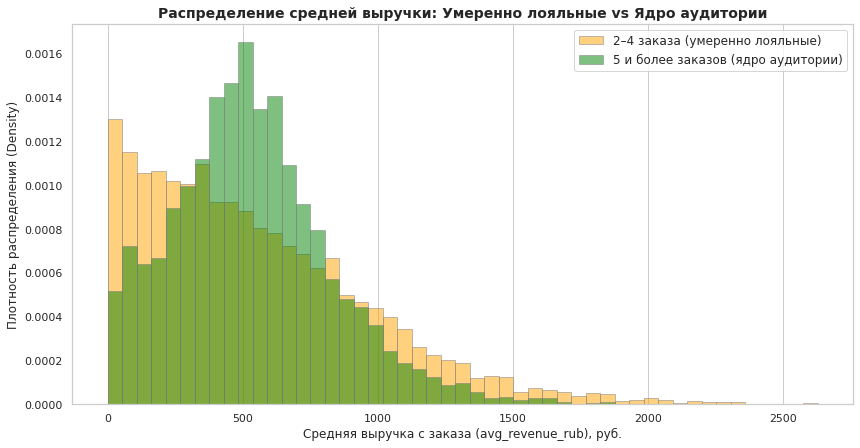

In [35]:
revenue_2_to_4 = user_profile_clean[
    (user_profile_clean['total_orders'] >= 2) & 
    (user_profile_clean['total_orders'] <= 4)
]['avg_revenue_rub']

revenue_5_plus = user_profile_clean[
    (user_profile_clean['is_five'] == 1)
]['avg_revenue_rub']


min_rev = min(revenue_2_to_4.min(), revenue_5_plus.min())
max_rev = max(revenue_2_to_4.max(), revenue_5_plus.max())
bins_shared = np.linspace(min_rev, max_rev, 50)

plt.figure(figsize=(14, 7))

plt.hist(revenue_2_to_4, bins=bins_shared, density=True, alpha=0.5, 
         color='orange', edgecolor='grey', label='2–4 заказа (умеренно лояльные)')
plt.hist(revenue_5_plus, bins=bins_shared, density=True, alpha=0.5, 
         color='green', edgecolor='grey', label='5 и более заказов (ядро аудитории)')

plt.title('Распределение средней выручки: Умеренно лояльные vs Ядро аудитории', fontsize=14, fontweight='bold')
plt.xlabel('Средняя выручка с заказа (avg_revenue_rub), руб.', fontsize=12)
plt.ylabel('Плотность распределения (Density)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

print(f"Медианная средняя выручка (2-4 заказа): {revenue_2_to_4.median():.2f} руб.")
print(f"Медианная средняя выручка (5+ заказов): {revenue_5_plus.median():.2f} руб.")

plt.show()

Различия распределения средней выручки у двух групп присутствуют. Ядро аудитории преобладает на диапазоне 400-750 рублей, на остальном - умеренно лояльные. Пользователи с 2-4 заказами принесли медианную среднюю выручку 471 рублей, а пользователи с 5+ заказами 513 рублей.

---

#### Влияние среднего количества билетов в заказе на вероятность повторной покупки.

---

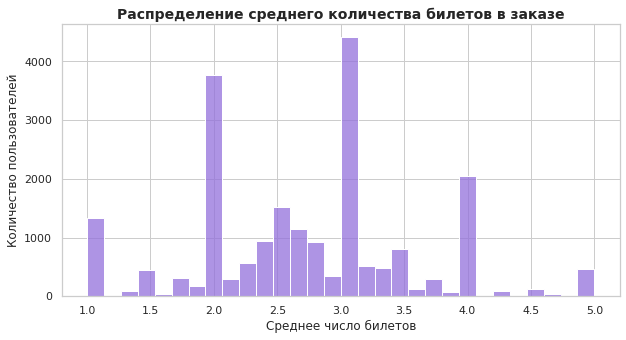

,Сегмент (кол-во билетов),Кол-во пользователей,Доля повторных заказов (%)
0,от 1 до 2,2410,51.24
1,от 2 до 3,9486,73.56
2,от 3 до 5,9065,54.30
3,5 и более,467,13.06


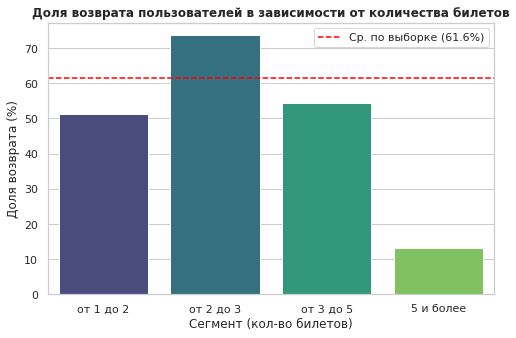

In [36]:
plt.figure(figsize=(10, 5))
sns.histplot(user_profile_clean['avg_tickets_count'], bins=30, color='mediumpurple')
plt.title('Распределение среднего количества билетов в заказе', fontsize=14, fontweight='bold')
plt.xlabel('Среднее число билетов', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.show()

bins = [0, 2, 3, 5, float('inf')]
labels = ['от 1 до 2', 'от 2 до 3', 'от 3 до 5', '5 и более']

user_profile_clean = user_profile_clean.copy()

user_profile_clean['tickets_segment'] = pd.cut(
    user_profile_clean['avg_tickets_count'], 
    bins=bins, 
    labels=labels, 
    right=False
)

segment_stats = user_profile_clean.groupby('tickets_segment', observed=True)['is_two'].agg(
    count='count',    
    mean='mean'       
).reset_index()

segment_stats['mean'] = segment_stats['mean'] * 100
segment_stats.rename(columns={
    'tickets_segment': 'Сегмент (кол-во билетов)',
    'count': 'Кол-во пользователей',
    'mean': 'Доля повторных заказов (%)'
}, inplace=True)

display(segment_stats.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=segment_stats, x='Сегмент (кол-во билетов)', y='Доля повторных заказов (%)', palette='viridis')
plt.title('Доля возврата пользователей в зависимости от количества билетов', fontsize=12, fontweight='bold')
plt.ylabel('Доля возврата (%)', fontsize=12)

global_mean = user_profile_clean['is_two'].mean() * 100
plt.axhline(global_mean, color='red', linestyle='--', label=f'Ср. по выборке ({global_mean:.1f}%)')
plt.legend()
plt.show()

Пики распределния среднего количества билетов в заказе заметны у целочисленных значений 1-5, особенно высокие у 2 и 3. Между этими значениями и заметен основной диапазон распределения.

Пользователи по сегментам распределены не равномерно. Особенно много пользователей в сегментах 2-3 билетов (9487 чел.) и 3-5 билетов (9064 чел.). В 1-2 билетов (2410 чел.) и 5+ билетов (467 чел.) значения меньше.

Очень высокий возврат пользователей заметен в сегменте 2-3 билета (примерно 73%), а крайне низкий у 5+ билетов (примерно 13%).

---

#### Исследование временных характеристик первого заказа и их влияния на повторные покупки

---

#### Анализ влияния дня недели, в который была совершена первая покупка, на поведение пользователей.

---


Статистика по дням недели первого заказа:


,День недели,Кол-во пользователей,Доля возврата (%)
0,Понедельник,2894,63.13
1,Вторник,3144,62.09
2,Среда,3031,62.55
3,Четверг,3086,59.66
4,Пятница,3230,60.06
5,Суббота,3295,63.03
6,Воскресенье,2748,60.52


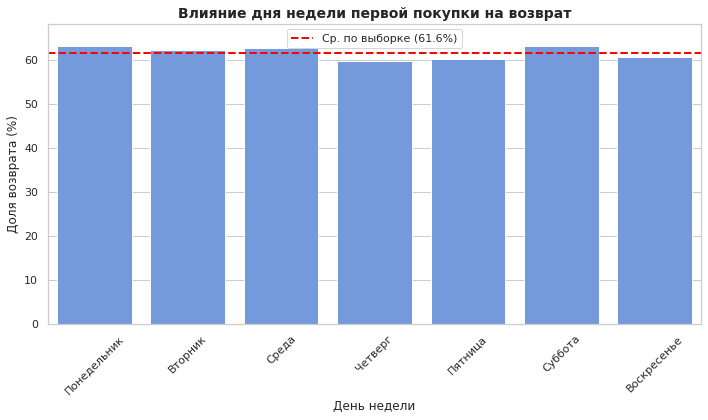

In [37]:
user_profile_clean = user_profile_clean.copy()

user_profile_clean['first_order_weekday_num'] = user_profile_clean['first_order_dt'].dt.dayofweek

weekday_names = {
    0: 'Понедельник', 1: 'Вторник', 2: 'Среда', 
    3: 'Четверг', 4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'
}

user_profile_clean['first_order_weekday'] = user_profile_clean['first_order_weekday_num'].map(weekday_names)

weekday_stats = user_profile_clean.groupby(['first_order_weekday_num', 'first_order_weekday'])['is_two'].agg(
    count='count',
    mean='mean'
).reset_index()

weekday_stats['mean'] = weekday_stats['mean'] * 100
weekday_stats.rename(columns={
    'first_order_weekday': 'День недели',
    'count': 'Кол-во пользователей',
    'mean': 'Доля возврата (%)'
}, inplace=True)

print("Статистика по дням недели первого заказа:")
display(weekday_stats[['День недели', 'Кол-во пользователей', 'Доля возврата (%)']].round(2))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=weekday_stats, 
    x='День недели', 
    y='Доля возврата (%)', 
    color='cornflowerblue'
)

global_mean = user_profile_clean['is_two'].mean() * 100
plt.axhline(global_mean, color='red', linestyle='--', linewidth=2, label=f'Ср. по выборке ({global_mean:.1f}%)')

plt.title('Влияние дня недели первой покупки на возврат', fontsize=14, fontweight='bold')
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Доля возврата (%)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, weekday_stats['Доля возврата (%)'].max() + 5)
plt.legend()
plt.tight_layout()
plt.show()

День недели первой покупки не особо влияет на возврат пользователя. Значения в диапазоне 59.66-63.13%. Немного чаще возвращаются купившие в понедельник или субботу.

---

#### Изучение, как средний интервал между заказами влияет на удержание клиентов.

---


=== Статистика интервалов между заказами (в днях) ===
Группа 2–4 заказа: Медиана = 9.0 | Среднее = 21.4
Группа 5+ заказов: Медиана = 8.1 | Среднее = 9.9



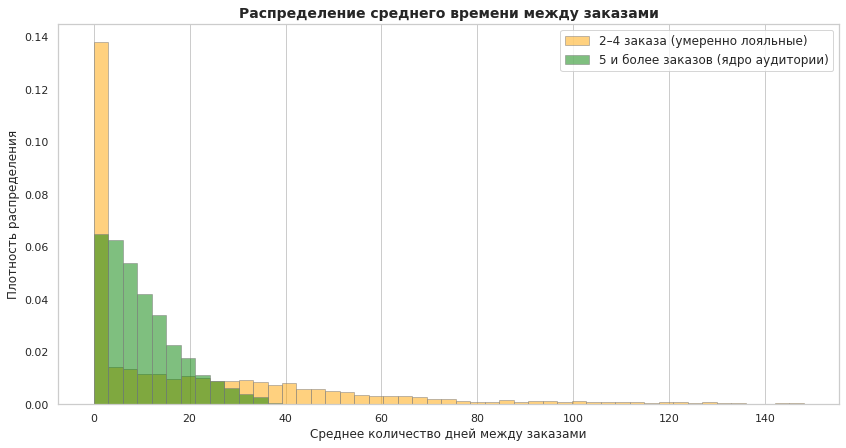

In [38]:
interval_2_to_4 = user_profile_clean[
    (user_profile_clean['total_orders'] >= 2) & 
    (user_profile_clean['total_orders'] <= 4)
]['avg_days_since_prev'].dropna()

interval_5_plus = user_profile_clean[
    (user_profile_clean['total_orders'] >= 5)
]['avg_days_since_prev'].dropna()

print("=== Статистика интервалов между заказами (в днях) ===")
print(f"Группа 2–4 заказа: Медиана = {interval_2_to_4.median():.1f} | Среднее = {interval_2_to_4.mean():.1f}")
print(f"Группа 5+ заказов: Медиана = {interval_5_plus.median():.1f} | Среднее = {interval_5_plus.mean():.1f}\n")

plt.figure(figsize=(14, 7))

min_days = min(interval_2_to_4.min(), interval_5_plus.min())
max_days = max(interval_2_to_4.max(), interval_5_plus.max())
bins_shared = np.linspace(min_days, max_days, 50)

plt.hist(interval_2_to_4, bins=bins_shared, density=True, alpha=0.5, 
         color='orange', edgecolor='grey', label='2–4 заказа (умеренно лояльные)')
plt.hist(interval_5_plus, bins=bins_shared, density=True, alpha=0.5, 
         color='green', edgecolor='grey', label='5 и более заказов (ядро аудитории)')

plt.title('Распределение среднего времени между заказами', fontsize=14, fontweight='bold')
plt.xlabel('Среднее количество дней между заказами', fontsize=12)
plt.ylabel('Плотность распределения', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

У умеренно лояльных чаще небольшое время между повторными заказами. При этом у них выражены случаи, когда между заказами проходило от 20 дней. Скорее всего умеренно лояльные часто берут билеты на серию мероприятий или просто находят развлечения на выходные (субботу-воскресенье). 
У ядра аудитории время между заказами варьируется от 0 до 30 дней, особенно на промежутке 0-10 дней. Они ходят на мероприятия хотя бы раз в месяц и часто раз в неделю.

---

#### Корреляционный анализ количества покупок и признаков пользователя

---

=== 1. Корреляция Phi_K с total_orders ===


,total_orders
avg_tickets_count,0.384
avg_revenue_rub,0.220
first_region,0.117
first_genre,0.028
first_partner,0.027
first_device,0.027



=== 2. Разброс значений в столбце total_orders ===


,count,mean,std,min,25%,50%,75%,max
total_orders,21428.0,6.538221,14.364726,1.0,1.0,2.0,5.0,152.0



Топ-5 самых частых количеств заказов (в % от всей базы):
Пользователей с 1 заказ(ами): 38.42%
Пользователей с 2 заказ(ами): 16.52%
Пользователей с 3 заказ(ами): 10.07%
Пользователей с 4 заказ(ами): 6.51%
Пользователей с 5 заказ(ами): 4.50%


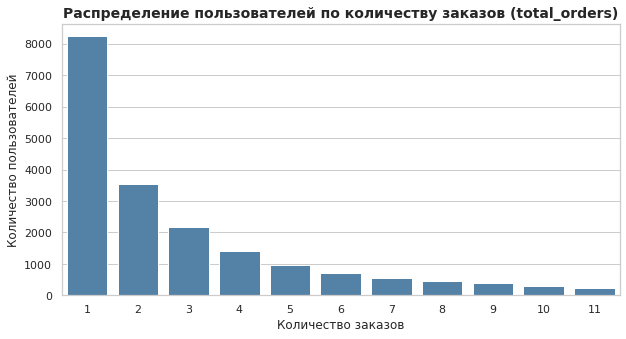

In [39]:
cols_to_correlate = [
    'total_orders', 'first_genre', 'first_device', 
    'first_region', 'first_partner', 'avg_revenue_rub', 'avg_tickets_count'
]
df_phik_raw = user_profile_clean[cols_to_correlate].copy()

interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count']

print("=== 1. Корреляция Phi_K с total_orders ===")
phik_matrix_raw = df_phik_raw.phik_matrix(interval_cols=interval_cols)

raw_corr = phik_matrix_raw[['total_orders']].drop('total_orders').sort_values(by='total_orders', ascending=False)
display(raw_corr.round(3))

print("\n=== 2. Разброс значений в столбце total_orders ===")

display(df_phik_raw['total_orders'].describe().to_frame().T)

top_values = df_phik_raw['total_orders'].value_counts(normalize=True).head(5) * 100
print("\nТоп-5 самых частых количеств заказов (в % от всей базы):")
for val, pct in top_values.items():
    print(f"Пользователей с {val} заказ(ами): {pct:.2f}%")


plt.figure(figsize=(10, 5))

sns.countplot(data=df_phik_raw, x='total_orders', color='steelblue')
plt.title('Распределение пользователей по количеству заказов (total_orders)', fontsize=14, fontweight='bold')
plt.xlabel('Количество заказов', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)

plt.xlim(-0.5, 10.5) 
plt.show()

Значения получились вполне адекватными, стандартное отклонение в total_orders равно 14.3806. Но проведем сегментацию.

=== 1. Базовая корреляция с total_orders ===


,total_orders
total_orders,1.000
avg_tickets_count,0.384
avg_revenue_rub,0.220
first_region,0.117
first_genre,0.028
first_partner,0.027
first_device,0.027



=== 2. Корреляция с сегментированным order_segment ===


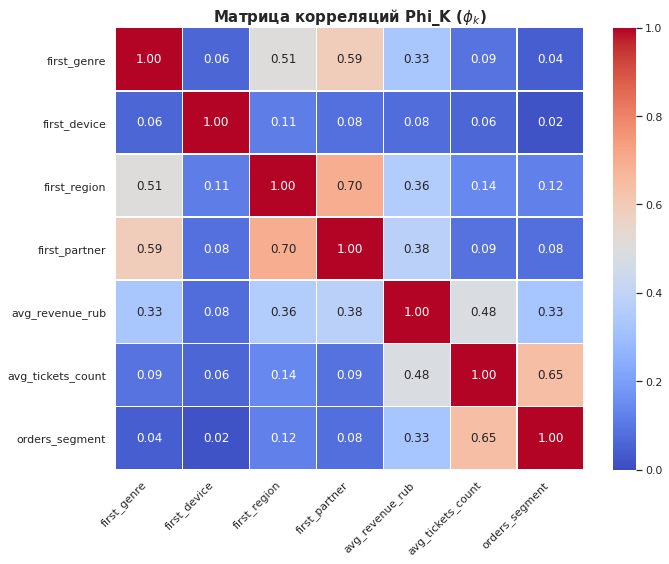


Связь признаков с количеством заказов (по убыванию):


,orders_segment
avg_tickets_count,0.647365
avg_revenue_rub,0.326117
first_region,0.124309
first_partner,0.081906
first_genre,0.040178
first_device,0.017554


In [40]:
cols_to_correlate = [
    'total_orders', 'first_genre', 'first_device', 
    'first_region', 'first_partner', 'avg_revenue_rub', 'avg_tickets_count'
]
df_phik = user_profile_clean[cols_to_correlate].copy()

interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count']

print("=== 1. Базовая корреляция с total_orders ===")

phik_matrix_base = df_phik.phik_matrix(interval_cols=interval_cols)
display(phik_matrix_base[['total_orders']].sort_values(by='total_orders', ascending=False).round(3))

def segment_orders(orders):
    if orders == 1:
        return '1 заказ'
    elif 2 <= orders <= 4:
        return '2-4 заказа'
    else:
        return '5 и более'

df_phik['orders_segment'] = df_phik['total_orders'].apply(segment_orders)

df_phik_segmented = df_phik.drop(columns=['total_orders'])

new_interval_cols = ['avg_revenue_rub', 'avg_tickets_count']

print("\n=== 2. Корреляция с сегментированным order_segment ===")

phik_matrix_segmented = df_phik_segmented.phik_matrix(interval_cols=new_interval_cols)


plt.figure(figsize=(10, 8))
sns.heatmap(
    phik_matrix_segmented, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    vmin=0, vmax=1,      
    linewidths=0.5
)
plt.title('Матрица корреляций Phi_K ($\phi_k$)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nСвязь признаков с количеством заказов (по убыванию):")
target_corr = phik_matrix_segmented['orders_segment'].drop('orders_segment').sort_values(ascending=False)
display(target_corr.to_frame())

Наиболее с общим количеством заказов у пользователей связаны среднее количество билетов и средняя выручка. Остальные признаки играют меньшую роль в количестве заказов клиента. 

### 5. Общий вывод и рекомендации

# Информация о данных
В рамках исследования были проанализированы данные о 290 611 заказах пользователей Яндекс Афиши. В выборку вошли заказы, совершённые с мобильных устройств и компьютеров, при этом мероприятия категории «фильм» были исключены согласно условиям исследования.

Выручка была представлена в российских рублях и казахстанских тенге. Для сопоставимости заказов суммы в тенге были пересчитаны в рубли по курсу на дату покупки, после чего сформирован единый показатель revenue_rub. Пропущенные значения были обнаружены только в столбце days_since_prev и соответствовали отсутствию предыдущего заказа. Типы данных были оптимизированы, а текстовые значения приведены к единому регистру и очищены от лишних пробелов. В распределении выручки были обнаружены крупные выбросы. После ограничения значений по 99-му перцентилю, равному 2628.42 руб., было удалено 3248 записей, или 1.12% исходной выборки. Для дальнейшего анализа осталось 287363 заказов.

На основе заказов были сформированы профили 21 838 пользователей. Из-за аномально большого количества заказов у отдельных пользователей и повышенного среднего количества билетов профили дополнительно были отфильтрованы по 99-м перцентилям. Было исключено 410 профилей, или 1.88%, после чего итоговая выборка составила 21 428 пользователя.

# Основные результаты
В исходной выборке профилей 61.7% пользователей совершили не менее двух заказов, а 29% - не менее пяти. После фильтрации доля пользователей с повторными заказами составила 61.58%, тогда как 38.42% пользователей ограничились одной покупкой.

Распределение пользователей по признакам первого заказа оказалось неравномерным. Основной точкой входа являются концерты: с них начали пользоваться сервисом 44.42% клиентов. Большинство первых заказов - 82.84% - было совершено с мобильных устройств. Среди регионов наибольшая доля пользователей приходится на Каменевский регион - 32.82%, а среди билетных партнеров выделяются «Билеты без проблем», «Мой билет» и «Лови билет!».

Повышенная доля повторных заказов наблюдалась у пользователей, впервые посетивших выставку, а также у клиентов, совершивших первую покупку с компьютера. Вместе с тем размер таких сегментов меньше размера основной аудитории, поэтому эти результаты следует интерпретировать осторожно.

Гипотеза о том, что пользователи, впервые купившие билет на спортивное мероприятие, возвращаются чаще посетителей концертов, не подтвердилась. Доля возврата после спортивных мероприятий составила 55.97%, а после концертов - 61.91%. Статистически значимой зависимости между количеством пользователей в регионе и долей повторных заказов также не обнаружено.

Средняя выручка с заказа связана с лояльностью пользователей. Медианная выручка для пользователей с одним заказом составила 374.95 руб., а для пользователей с двумя и более заказами - 495.92 руб. Среди пользователей с 2-4 заказами медианная выручка составила 471.04 руб., а среди пользователей с пятью и более заказами - 513.09 руб. Таким образом, более лояльные пользователи в среднем совершают более доходные покупки.

Наиболее высокая доля повторных покупок - 73.56% - выявлена среди пользователей, приобретающих в среднем от двух до трёх билетов. Среди пользователей со средним заказом от пяти билетов доля возврата составила только 13.06%. При этом данный сегмент относительно мал и включает 467 пользователей, поэтому его следует анализировать отдельно.

День недели первой покупки практически не влияет на вероятность возврата: значения доли повторных заказов находятся в узком диапазоне от 59.64 до 63.18%. Несколько более высокий показатель наблюдается среди пользователей, впервые совершивших заказ в понедельник или субботу. Пользователи с пятью и более заказами отличаются более стабильными интервалами между покупками, тогда как среди пользователей с 2-4 заказами чаще встречаются продолжительные перерывы.

Корреляционный анализ с использованием коэффициента Phi_K показал, что с количеством заказов наиболее сильно связаны среднее количество билетов и средняя выручка с заказа. После разделения пользователей на сегменты коэффициент связи со средним количеством билетов составил 0.647, а со средней выручкой - 0.326. Связь с регионом оказалась значительно слабее - 0.124. Тип первого мероприятия, устройство и билетный партнёр имеют сравнительно небольшую связь с количеством заказов. При этом обнаруженные зависимости не доказывают причинного влияния признаков на поведение пользователей.

# Рекомендации
Основное внимание стоит уделить пользователям, покупающим от двух до трех билетов и совершающим заказы со средней выручкой примерно от 350 до 1000 руб. Этот сегмент сочетает высокую долю повторных покупок и значительный размер и поэтому является наиболее перспективным для программ лояльности, персональных рекомендаций и стимулирования последующих заказов. Концерты и мобильные устройства следует рассматривать как главные точки привлечения пользователей. Хотя эти сегменты не всегда показывают максимальную долю возврата, через них приходит основная часть аудитории. Для новых мобильных пользователей после покупки билета на концерт лучше использовать персональные подборки похожих мероприятий, напоминания и предложения для повторной покупки.

Пользователей, приобретающих в среднем пять и более билетов, рекомендуется выделить в отдельный сегмент. Низкая доля возврата может быть связана с групповыми, корпоративными или разовыми заказами. Для этой аудитории могут быть эффективнее специальные групповые предложения и отдельные коммуникации, а не стандартная программа лояльности. Сегменты с повышенной долей возврата, например посетителей выставок и пользователей компьютеров, можно использовать для проведения пилотных маркетинговых кампаний. Для удержания пользователей с 2-4 заказами рекомендуется протестировать коммуникации, направленные на сокращение длительных перерывов между покупками: напоминания о новых мероприятиях, тематические подборки и персональные предложения.